In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [4]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [5]:
X.shape

(1000, 2)

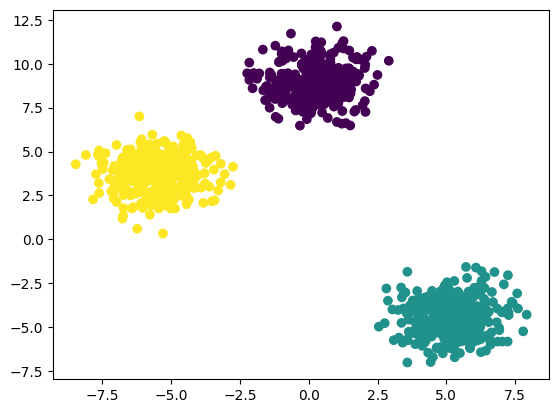

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [8]:
from sklearn.cluster import KMeans

In [9]:
# Manual Process
# Elbow Method to select the K Value

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)


In [10]:
wcss

[34827.57682552021,
 7935.4372861454185,
 1319.2730531585607,
 1186.4254781042152,
 1004.9537973599425,
 904.9986215189132,
 768.5890651589954,
 700.9131718077114,
 619.0197057535538,
 544.8376999339065]

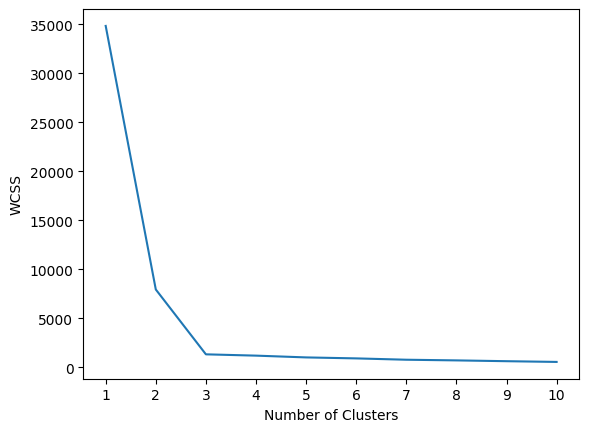

In [11]:
# plot elbow curve

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [19]:
y_labels=kmeans.fit_predict(X_train)

In [25]:
y_test_label=kmeans.predict(X_test)

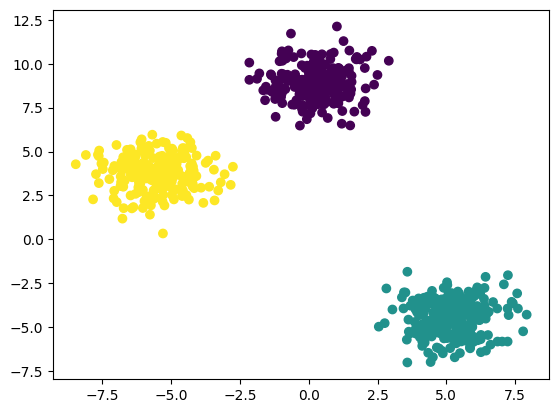

In [22]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

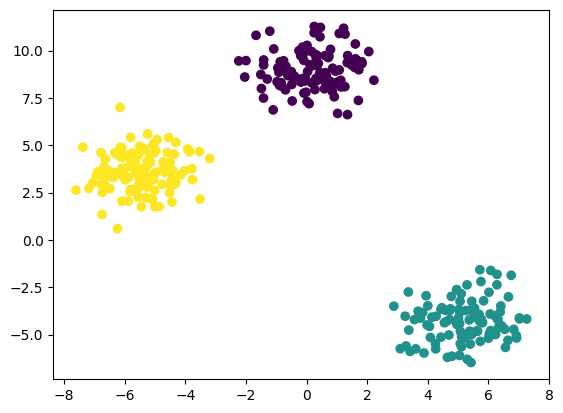

In [27]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)


In [28]:
## Knee Locator

!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [29]:
from kneed import KneeLocator

In [30]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [32]:
## Performance Metrics
## Silhoutte Score

from sklearn.metrics import silhouette_score

In [34]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [35]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6045426117136103,
 0.6264377501992732,
 0.3286247130487611,
 0.3419090742001682,
 0.33171696527186284,
 0.3425640026144706,
 0.3409002159767753]

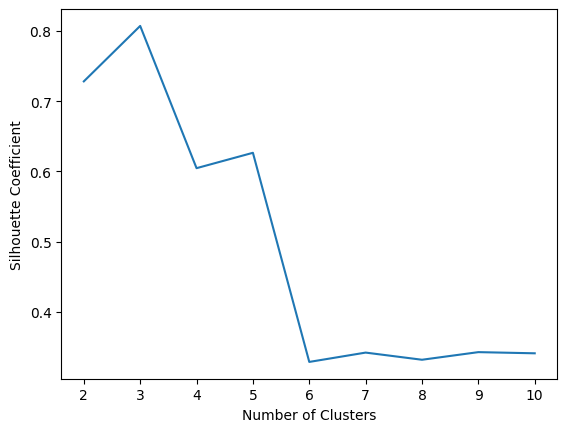

In [37]:
## Pllotting Silhouette Score

plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()